<a href="https://colab.research.google.com/github/Tejaswimadastu/Machine_Learning/blob/main/PCA_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal Component Analysis

Loading iris dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
iris=load_iris()

In [3]:
x=iris.data
y=iris.target
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
x_scaler=StandardScaler().fit_transform(x)

In [6]:
x.shape

(150, 4)

# Apply PCA and get Scree plot

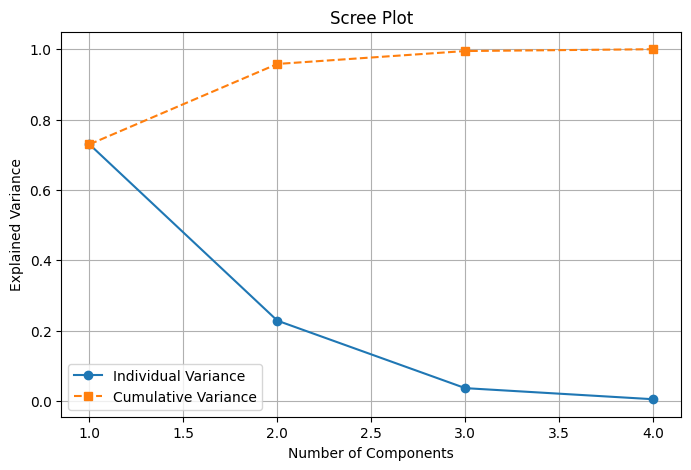

In [8]:
import numpy as np
pca=PCA()
pca.fit_transform(x_scaler)
 #scree plot
plt.figure(figsize=(8,5))

# Individual explained variance
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, 'o-', label='Individual Variance')

# Cumulative explained variance
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), 's--', label='Cumulative Variance')

plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.legend()
plt.show()

# Choose Number of Components (95% Variance)

In [10]:
pca_95=PCA(n_components=0.95)
x_reduced=pca_95.fit_transform(x_scaler)
print(f"Reduced Shape :{x_reduced.shape}")

Reduced Shape :(150, 2)


# Visualize top 2 Components

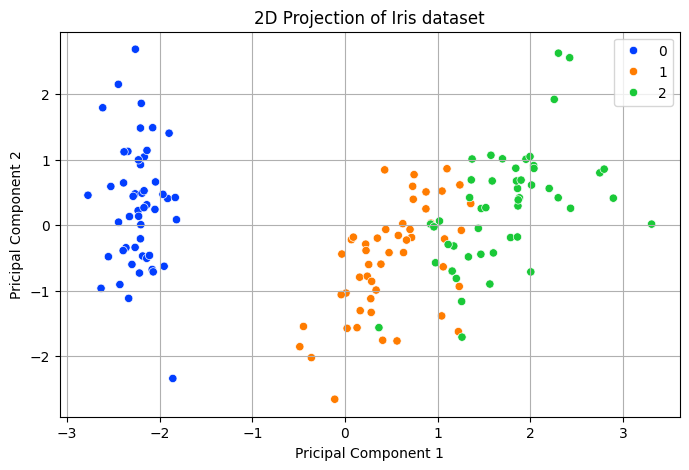

In [16]:
pca_2d=PCA(n_components=2)
x_reduced_2d=pca_2d.fit_transform(x_scaler)
plt.figure(figsize=(8,5))
sns.scatterplot(x=x_reduced_2d[:,0],y=x_reduced_2d[:,1],hue=y,palette='bright')
plt.xlabel("Pricipal Component 1")
plt.ylabel("Pricipal Component 2")
plt.title('2D Projection of Iris dataset')
plt.grid(True)
plt.show()